# 👨🏻‍💻 **CRISPr L3 Workshop Exercise** 👨🏻‍💻

## Setup

1) File >> Open notebook >> Github
2) Paste the ***REPO URL*** to gitclone


In [14]:
!rm -rf /content/CRISPrWorkshop

In [15]:
!git clone https://github.com/zendenleong/CRISPrWorkshop.git

Cloning into 'CRISPrWorkshop'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 2.71 MiB | 3.65 MiB/s, done.


In [16]:
ls CRISPrWorkshop/

CRISPr_notebook.ipynb          hdb_resale_golden.csv       README.md
hdb_resale_data_contract.yaml  hdb_resale_with_errors.csv


## Section 1: Demo of vowl-ui and vowl-canvas

vowl-ui is a data validation application where you can upload, validate and evaluate data quality with the help of a data contract.

In this demo, we will be using _**hdb_resale_data_contract.yaml**_ to validate
 _**hdb_resale_with_errors.csv**_ on vowl-ui, getting a comprehensive overview of data validation results and data quality dimensions.


**vowl-ui**

https://vowl-ui.gvt-build26-data-practice.stg.paas.sandbox.gov.sg









_**Now that you have seen the data quality dashboard, you might be wondering how do we generate this data contract?**_

We can generate a data contract on vowl-canvas with a golden dataset. A golden dataset is a prime example of validated, high-quality data that represents the expected data quality and structure. vowl-canvas will learn from the values to infer precise validation rules, data patterns and constraints for optimal contract generation. We will be using ***hdb_resale_golden.csv***.



**vowl-canvas**

https://vowl-canvas.gvt-build26-data-practice.stg.paas.sandbox.gov.sg

## Section 2: Validation of HDB Resale data using vowl library

In this section, you will try out the data validation process via the vowl library in code instead of an UI.

In [17]:
!pip install vowl

In [18]:
import pandas as pd
from io import StringIO
from vowl import validate_data

Validating hdb resale data with vowl library

In [19]:
df = pd.read_csv("/content/CRISPrWorkshop/hdb_resale_with_errors.csv")

/tmp/ipykernel_863/2081188992.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/CRISPrWorkshop/hdb_resale_with_errors.csv")


In [20]:
result = validate_data("/content/CRISPrWorkshop/hdb_resale_data_contract.yaml", df=df)

/usr/local/lib/python3.12/dist-packages/vowl/validation/runner.py:70: UserWarning: Arrow type conversion failed, loading problematic columns as strings: lease_commence_date. Type validation will occur in DQ checks. Original error: ("Expected bytes, got a 'int' object", 'Conversion failed for column lease_commence_date with type object')
  resolved[schema_name] = mapper.get_adapter(adapter_input, schema_name)


In [21]:
result.display_full_report()



=== Data Quality Validation Results ===
   Contract Version:      v3.1.0
   Contract ID:           c11443ee-542f-4442-b28d-2d224342be37
   Schemas:               hdb_resale_prices

 OVERALL DATA QUALITY
   Overall:
     Checks Pass Rate:       41 / 54 (75.9%)

   hdb_resale_prices:
     Overall:
       Checks Pass Rate:       41 / 54 (75.9%)
       ERRORED Checks:         0
     Single Table:
       Checks Pass Rate:       41 / 54 (75.9%)
       ERRORED Checks:         0
       Unique Passed Rows:     201,558 / 201,879 (99.8%)
     Multi Table:
       Checks Pass Rate:       0 / 0 (N/A)
       ERRORED Checks:         0
       Non-unique Failed Rows: 0


 CHECK RESULTS
+----------------------------------------------------+---------------------------------------+-------------------+--------+-------------------+----------+--------+----------------+
| check_id                                           | Target                                | tables_in_query   | status | operator        

ValidationResult(passed=False, checks=54, passed_checks=41, failed_checks=13)

## Data Quality Reporting

In [22]:
for key,value in result.__dict__.items():
  print(key,value)

#print(result.__dict__)

summary {'validation_summary': {'total_checks': 54, 'passed': 41, 'failed': 13, 'errors': 0, 'total_rows_by_schema': {'hdb_resale_prices': 201879}, 'config': {'max_rows_for_statistics': -1, 'enable_additional_schema_statistics': True, 'max_failed_rows': -1, 'use_try_cast': True, 'output_mode': 'failed_rows', 'annotated_check_info': 'names'}, 'failed_rows': 629, 'total_execution_time_ms': 3758.4649940022246, 'success_rate': 75.92592592592592, 'connection_results': {'hdb_resale_prices': {'hdb_resale_prices': 'success'}}}, 'check_results': [{'name': 'month_column_exists_check', 'status': 'PASSED', 'details': "Column 'month' must exist in 'hdb_resale_prices'", 'expected_value': 0, 'actual_value': 0, 'failed_rows_count': 0, 'execution_time_ms': 27.539221000097314, 'check_path': '$.schema[0].properties[0].name', 'check_ref_type': 'DeclaredColumnExistsCheckReference', 'schema_name': 'hdb_resale_prices', 'operator': 'mustBe', 'is_generated': True, 'engine': 'sql', 'check_definition': {'name': 

In [23]:
def print_quality_dimensions_summary(result):
    check_results = result.summary['check_results']

    dimensions = {}
    for check in check_results:
        dimension = check['check_definition'].get('dimension', 'uncategorized')
        if dimension not in dimensions:
            dimensions[dimension] = {'total': 0, 'passed': 0, 'failed_records': 0}
        dimensions[dimension]['total'] += 1
        if check['status'] == 'PASSED':
            dimensions[dimension]['passed'] += 1
        dimensions[dimension]['failed_records'] += check['failed_rows_count']

    print("=" * 60)
    print("Quality Dimensions Breakdown")
    print("=" * 60)
    for dimension, stats in sorted(dimensions.items()):
        pass_rate = (stats['passed'] / stats['total'] * 100) if stats['total'] > 0 else 0
        print(f"\n{dimension.upper()}")
        print(f"  Rules Passed: {stats['passed']}/{stats['total']} ({pass_rate:.1f}%)")
        print(f"  Failed Records: {stats['failed_records']}")
    print("\n" + "=" * 60)

In [24]:
print_quality_dimensions_summary(result)

Quality Dimensions Breakdown

ACCURACY
  Rules Passed: 0/1 (0.0%)
  Failed Records: 1

COMPLETENESS
  Rules Passed: 12/15 (80.0%)
  Failed Records: 4

CONFORMITY
  Rules Passed: 29/37 (78.4%)
  Failed Records: 28

UNIQUENESS
  Rules Passed: 0/1 (0.0%)
  Failed Records: 596



In [25]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

def get_dimension_scores(result, timestamp):
    """Extract pass rate per dimension from a validation result."""
    check_results = result.summary['check_results']

    dimensions = {}
    for check in check_results:
        dimension = check['check_definition'].get('dimension', 'uncategorized')
        if dimension not in dimensions:
            dimensions[dimension] = {'total': 0, 'passed': 0}
        dimensions[dimension]['total'] += 1
        if check['status'] == 'PASSED':
            dimensions[dimension]['passed'] += 1

    scores = {'timestamp': timestamp}
    for dim in ['accuracy', 'completeness', 'conformity']:
        if dim in dimensions and dimensions[dim]['total'] > 0:
            scores[dim] = dimensions[dim]['passed'] / dimensions[dim]['total'] * 100
        else:
            scores[dim] = None
    return scores

 
 
--------------- FAILED RECORDS ARTIFACTS SENT TO S3 ----------------- 
---------- DQ METRICS SENT TO DQ MONITORING CENTRAL SERVER ----------
 
 


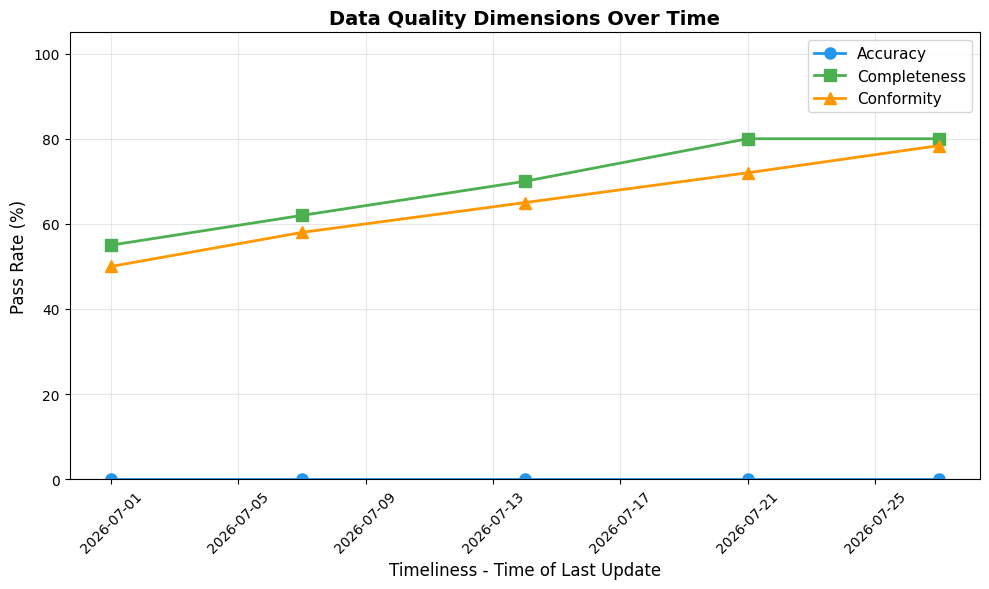

In [26]:
# Mock historical data showing improvement over time
quality_history = [
    {'timestamp': '2026-07-01T00:00:00+08:00', 'accuracy': 0.0, 'completeness': 55.0, 'conformity': 50.0},
    {'timestamp': '2026-07-07T00:00:00+08:00', 'accuracy': 0.0, 'completeness': 62.0, 'conformity': 58.0},
    {'timestamp': '2026-07-14T00:00:00+08:00', 'accuracy': 0.0, 'completeness': 70.0, 'conformity': 65.0},
    {'timestamp': '2026-07-21T00:00:00+08:00', 'accuracy': 0.0, 'completeness': 80.0, 'conformity': 72.0},
]

# Add today's actual result
current_scores = get_dimension_scores(result, '2026-07-27T00:00:00+08:00')
quality_history.append(current_scores)

#print("Quality History Dictionary:")
#for entry in quality_history:
    #print(entry)

# Plot the line graph
def plot_quality_trend(quality_history):
    timestamps = [datetime.fromisoformat(entry['timestamp']) for entry in quality_history]
    accuracy = [entry['accuracy'] for entry in quality_history]
    completeness = [entry['completeness'] for entry in quality_history]
    conformity = [entry['conformity'] for entry in quality_history]

    plt.figure(figsize=(10, 6))
    plt.plot(timestamps, accuracy, 'o-', label='Accuracy', color='#2196F3', linewidth=2, markersize=8)
    plt.plot(timestamps, completeness, 's-', label='Completeness', color='#4CAF50', linewidth=2, markersize=8)
    plt.plot(timestamps, conformity, '^-', label='Conformity', color='#FF9800', linewidth=2, markersize=8)

    plt.xlabel('Timeliness - Time of Last Update', fontsize=12)
    plt.ylabel('Pass Rate (%)', fontsize=12)
    plt.title('Data Quality Dimensions Over Time', fontsize=14, fontweight='bold')
    plt.ylim(0, 105)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print(" ")
print(" ")
print('--------------- FAILED RECORDS ARTIFACTS SENT TO S3 ----------------- ')
print('---------- DQ METRICS SENT TO DQ MONITORING CENTRAL SERVER ----------')
print(" ")
print(" ")
plot_quality_trend(quality_history)


## Section 3: Create your own data contract using your own golden dataset and validate against your own data

Now that we have seen how to generate a data contract via vowl-canvas and validate data via vowl-ui, it is your turn to try it out! :D

You will need to first create your own data contract ***data_contract.yaml*** using your own golden dataset.

The following steps are for validating data using vowl library instead of using vowl-ui:


Step 1: You can upload your ***dataset.csv*** and ***data_contract.yaml*** *into the* ***CRISPrWorkshop folder***.

COMET users will need a workaround since the upload function is restricted.   


SEED users: Refer to Step 1.1

COMET users: Refer to Step 1.2

Step 1.1: SEED users
- From left sidebar, open files icon

- Upload your ***dataset.csv*** and ***data_contract.yaml*** in ***CRISPrWorkshop*** folder
- Ensure that the files are in correct folder
- Go to Step 2


In [27]:
!ls "/content/CRISPrWorkshop/"

CRISPr_notebook.ipynb	       hdb_resale_golden.csv	   README.md
hdb_resale_data_contract.yaml  hdb_resale_with_errors.csv


Step 1.2: COMET users
- COMET users need a workaround to get your dataset file into google drive due to limitation of upload function in google drive. However, you can still upload csv and yaml files in vowl-ui.
- Use any text editor like vscode to copy & paste the csv file and yaml file in the empty space below and write into the ***CRISPrWorkshop*** folder

  OR

- Go to vowl-ui and copy & paste the csv file and yaml file into the empty space below and write into ***CRISPrWorkshop*** folder

### ---- WORKAROUND FOR COMET USERS TO WRITE CSV ----


In [28]:
#CHANGE YOUR DATA SET AND DATA CONTRACT FILE NAMES HERE

dataset_name = 'dataset.csv'
datacontract_name = 'data_contract.yaml'

In [29]:
csv_data = """

<PASTE COPIED CSV OVER HERE>

"""

df = pd.read_csv(StringIO(csv_data))

file_path = f"/content/CRISPrWorkshop/{dataset_name}"
df.to_csv(file_path, index=False)

print(f"Saved to {file_path}")

Saved to /content/CRISPrWorkshop/dataset.csv


### ---- WORKAROUND FOR COMET USERS TO WRITE DATA CONTRACT YAML ----

In [30]:
yaml_content = r"""

<PASTE COPIED YAML OVER HERE>

"""

file_path = f"/content/CRISPrWorkshop/{datacontract_name}"

with open(file_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Saved to {file_path}")

Saved to /content/CRISPrWorkshop/data_contract.yaml


In [31]:
!ls "/content/CRISPrWorkshop/"

CRISPr_notebook.ipynb  hdb_resale_data_contract.yaml  README.md
data_contract.yaml     hdb_resale_golden.csv
dataset.csv	       hdb_resale_with_errors.csv


Step 2: Validating your own data with vowl library

In [ ]:
#Ensure that the file path is correct
df1 = pd.read_csv(f"/content/CRISPrWorkshop/{dataset_name}")
df1

In [ ]:
result1 = validate_data(f"/content/CRISPrWorkshop/{datacontract_name}", df=df1)

In [ ]:
result1.display_full_report()